In [1]:
import os
os.environ["PYTHONWARNINGS"] = "ignore"

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import scanpy as sc
import squidpy as sq
import pandas as pd
import numpy as np
import gseapy as gp
import decoupler as dc
import pickle
import enrichmap as em

In [4]:
sc.set_figure_params(frameon=False)
sc.settings._vector_friendly = False

In [5]:
# set working directory
# repository root (the folder containing `notebooks/`); safe to re-run this cell
project_dir = os.getcwd()
if os.path.basename(project_dir) == "notebooks":
    project_dir = os.path.dirname(project_dir)
project_dir += "/"
working_dir = project_dir + ""
os.chdir(working_dir)

# set figure directory
figure_dir = working_dir + "figures/"
os.makedirs(figure_dir, exist_ok=True)

# processed data directory
processed_data = working_dir + "processed_data/"
os.makedirs(processed_data, exist_ok=True)


In [6]:
spot_size = 1.5

In [7]:
adata = sq.datasets.visium_hne_adata()

In [8]:
adata.layers["counts"] = adata.raw.X.copy()

In [9]:
adata.X = adata.layers["counts"].copy()

In [10]:
sc.pp.filter_genes(adata, min_cells=1)
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata.layers["log1p_norm"] = adata.X.copy()

In [11]:
with open("Pyramidal_layer_signatures.pkl", "rb") as f:
    signature_dict = pickle.load(f)

In [12]:
gene_set = signature_dict["Pyramidal_top20"]

### EnrichMap

In [13]:
em.tl.score(adata, gene_set)

Scoring signatures: 100%|██████████| 1/1 [00:02<00:00,  2.56s/it]


In [14]:
from anndata import AnnData
import squidpy as sq

def spatial_smooth(
    adata: AnnData,
    score_key: str,
    n_neighbors: int = 6,
    batch_key: str | None = None,
    result_key: str | None = None,
) -> None:
    """
    Apply spatial neighbourhood smoothing to any numeric score stored in adata.obs.

    For each cell or spot j, the smoothed score is computed as:

        S_j = (1 / sum(A_jk)) * sum(A_jk * Z_k)

    where A is the adjacency matrix of the spatial neighbours graph
    and the sum runs over neighbours of j.

    Parameters
    ----------
    adata : AnnData
        Annotated data matrix with spatial coordinates in obsm.
    score_key : str
        Column in adata.obs containing the scores to smooth.
    n_neighbors : int, default 6
        Number of nearest spatial neighbours.
    batch_key : str or None, optional
        Column in adata.obs indicating batch labels. When provided,
        smoothing is performed independently within each batch.
    result_key : str or None, optional
        Column name for the smoothed scores in adata.obs.
        Defaults to '{score_key}_smoothed'.

    Returns
    -------
    None
        Smoothed scores are stored in adata.obs[result_key].
    """
    if score_key not in adata.obs.columns:
        raise KeyError(f"'{score_key}' not found in adata.obs")

    if result_key is None:
        result_key = f"{score_key}_smoothed"

    raw = adata.obs[score_key].values.astype(float).copy()
    smoothed = raw.copy()

    batches = adata.obs[batch_key].unique() if batch_key else [None]

    for batch in batches:
        mask = (
            adata.obs[batch_key] == batch if batch_key else np.ones(adata.n_obs, bool)
        )
        adata_batch = adata[mask].copy()
        sq.gr.spatial_neighbors(
            adata_batch,
            n_neighs=n_neighbors,
            coord_type="generic",
            key_added="spatial",
        )
        conn = adata_batch.obsp["spatial_connectivities"]
        smoothed[mask] = conn.dot(raw[mask]) / np.maximum(conn.sum(axis=1).A1, 1e-10)

    adata.obs[result_key] = smoothed

### AUCell

In [15]:
# convert the signature dict to a long format
signatures_dict = {"Pyramidal_layer": gene_set}

signatures_df = pd.DataFrame(
    [(key, gene) for key, genes in signatures_dict.items() for gene in genes],
    columns=["source", "target"]
)

dc.mt.aucell(adata, net=signatures_df)

score_aucell = dc.pp.get_obsm(adata=adata, key="score_aucell")
adata.obs["aucell_score"] = score_aucell.obsm["score_aucell"]

### `score_genes()`/`AddModuleScore()`

In [16]:
sc.tl.score_genes(adata, gene_set, score_name="scanpy_score", layer="log1p_norm")

## ssGSEA

In [17]:
# If adata.X is sparse, convert to dense first
X_dense = adata.X.toarray() if not isinstance(adata.X, np.ndarray) else adata.X

# Create DataFrame using var names as columns and obs names as index
gene_expr = pd.DataFrame(X_dense.T, index=adata.var_names, columns=adata.obs_names)

In [18]:
gene_expr.index = gene_expr.index.str.upper()
signatures_dict = {k: [g.upper() for g in v] for k, v in signatures_dict.items()}

In [19]:
ssgsea = gp.ssgsea(
    data=gene_expr,
    gene_sets=signatures_dict,
    outdir=None,
    sample_norm_method="rank",
    no_plot=True,
    min_size=5
)

In [20]:
nes = ssgsea.res2d.pivot(index="Term", columns="Name", values="NES")
adata.obs["ssgsea_score"] = nes.loc["Pyramidal_layer"].T.astype(float).reindex(adata.obs_names)

### GSVA

In [21]:
gsva = gp.gsva(
    data=gene_expr,
    gene_sets=signatures_dict,
    outdir=None,
    min_size=5
)
es = gsva.res2d.pivot(index="Term", columns="Name", values="ES")
adata.obs["gsva_score"] = es.loc["Pyramidal_layer"].T.astype(float).reindex(adata.obs_names)

### Z score

In [23]:
gene_set = signatures_dict["Pyramidal_layer"]
z_score = gene_expr.loc[gene_set].sum(axis=0) / np.sqrt(len(gene_set))
adata.obs["z_score"] = z_score

In [24]:
methods = ["enrichmap_score", "aucell_score", "z_score", "scanpy_score", "ssgsea_score", "gsva_score"]

In [25]:
for method in (m for m in methods if m != "enrichmap_score"):
    spatial_smooth(
        adata,
        score_key=method,
        n_neighbors=6,
        result_key=f"{method}"
    )

Computing Moran's I for enrichmap_score with 6 neighbours...
Computing Moran's I for aucell_score with 6 neighbours...
Computing Moran's I for z_score with 6 neighbours...
Computing Moran's I for scanpy_score with 6 neighbours...
Computing Moran's I for ssgsea_score with 6 neighbours...
Computing Moran's I for gsva_score with 6 neighbours...


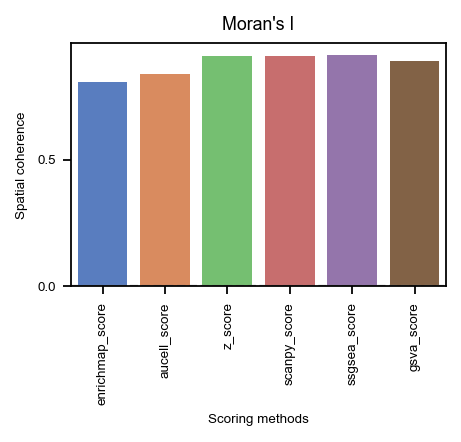

In [26]:
em.pl.spatial_metrics(
    adata,
    score_keys=methods,
    metric="Moran's I",
    figsize=(3, 2),
    save="visium_brain_enrichmap_score_moransI_with_smoothing.pdf",
)

Computing Geary's C for enrichmap_score with 6 neighbours...
Computing Geary's C for aucell_score with 6 neighbours...
Computing Geary's C for z_score with 6 neighbours...
Computing Geary's C for scanpy_score with 6 neighbours...
Computing Geary's C for ssgsea_score with 6 neighbours...
Computing Geary's C for gsva_score with 6 neighbours...


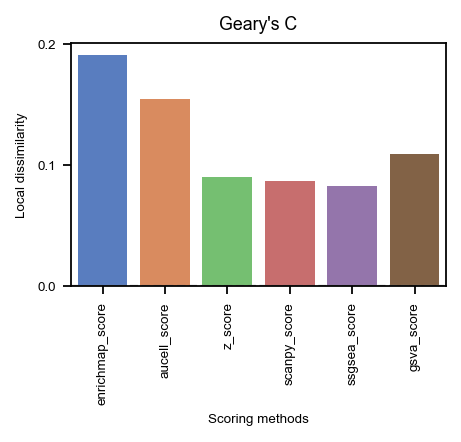

In [27]:
em.pl.spatial_metrics(
    adata,
    score_keys=methods,
    metric="Geary's C",
    figsize=(3, 2),
    save="visium_brain_enrichmap_score_gearysC_with_smoothing.pdf",
)

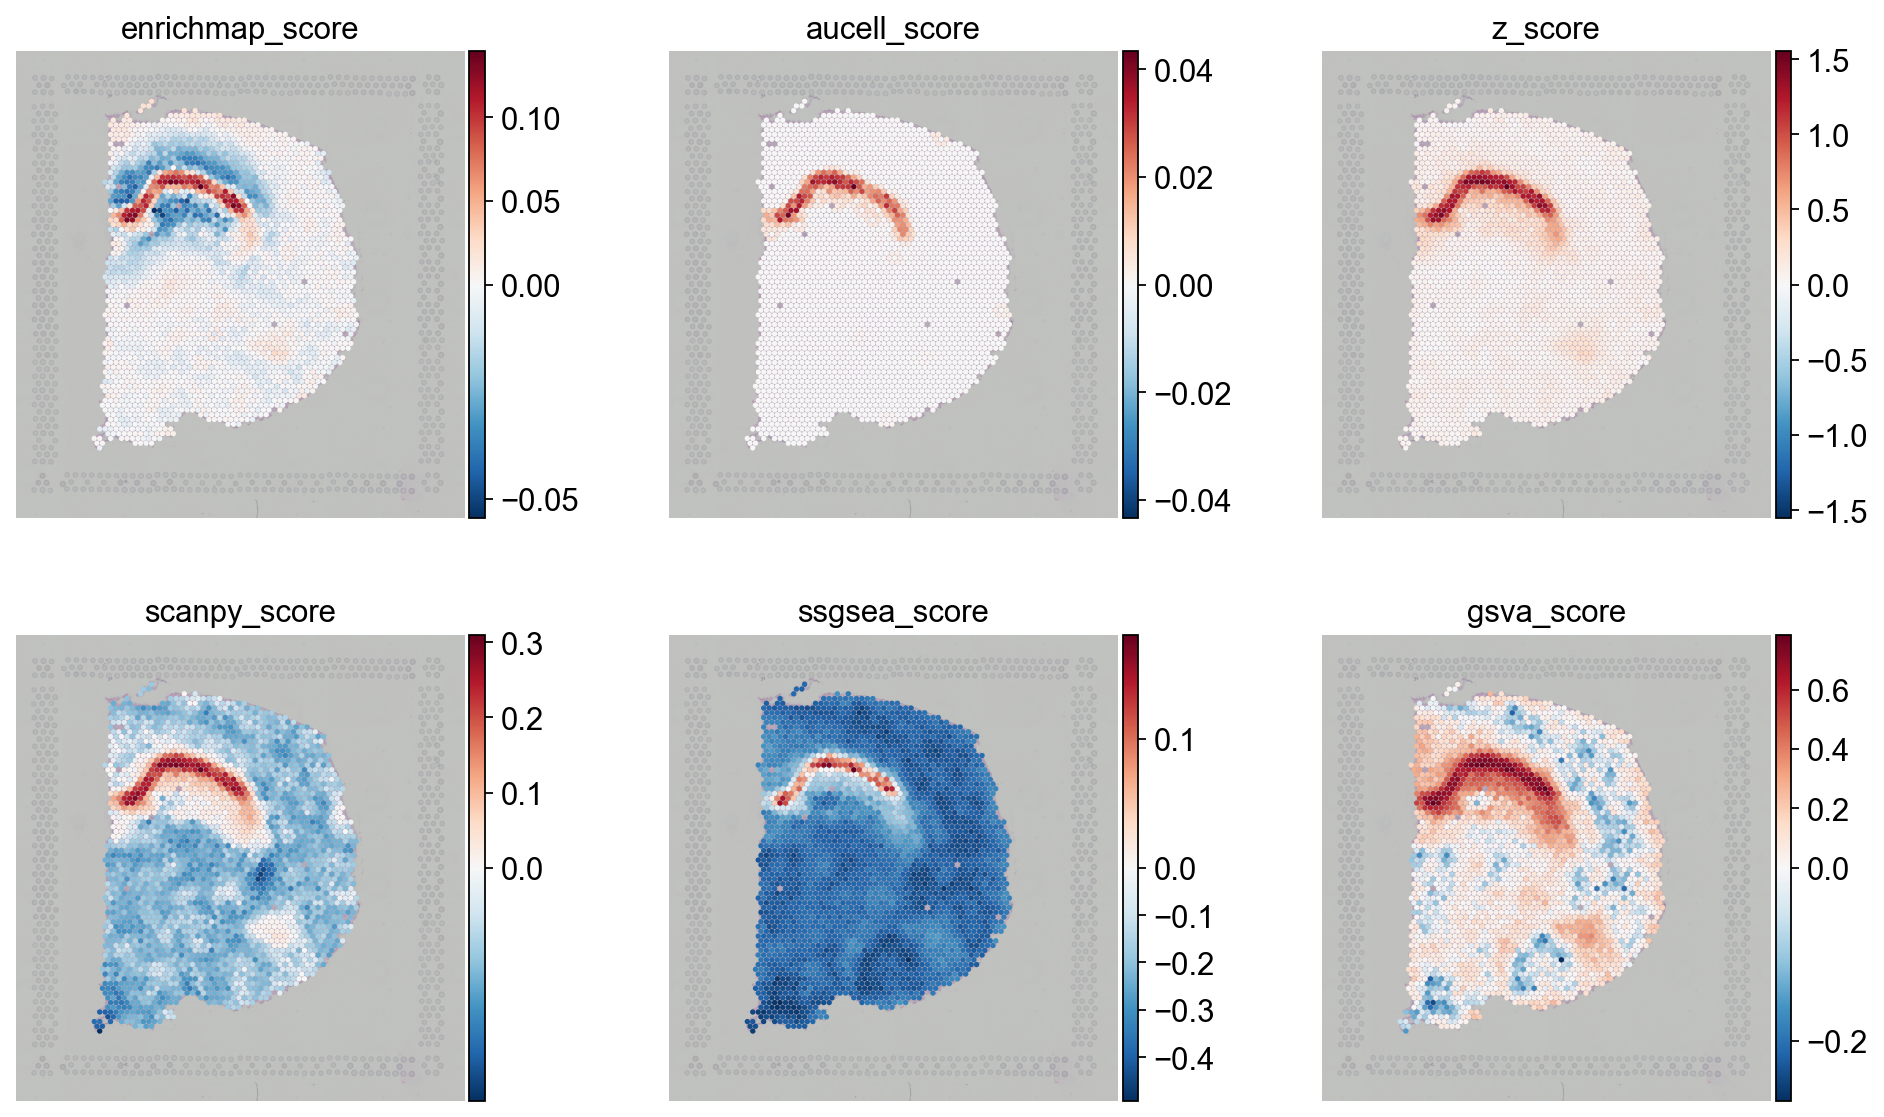

In [28]:
sq.pl.spatial_scatter(
    adata,
    color=methods,
    img_alpha=0.5,
    size=spot_size,
    ncols=3,
    vcenter=0,
    cmap="RdBu_r",
    save="visium_brain_enrichmap_score_all_with_smoothing.pdf",
)

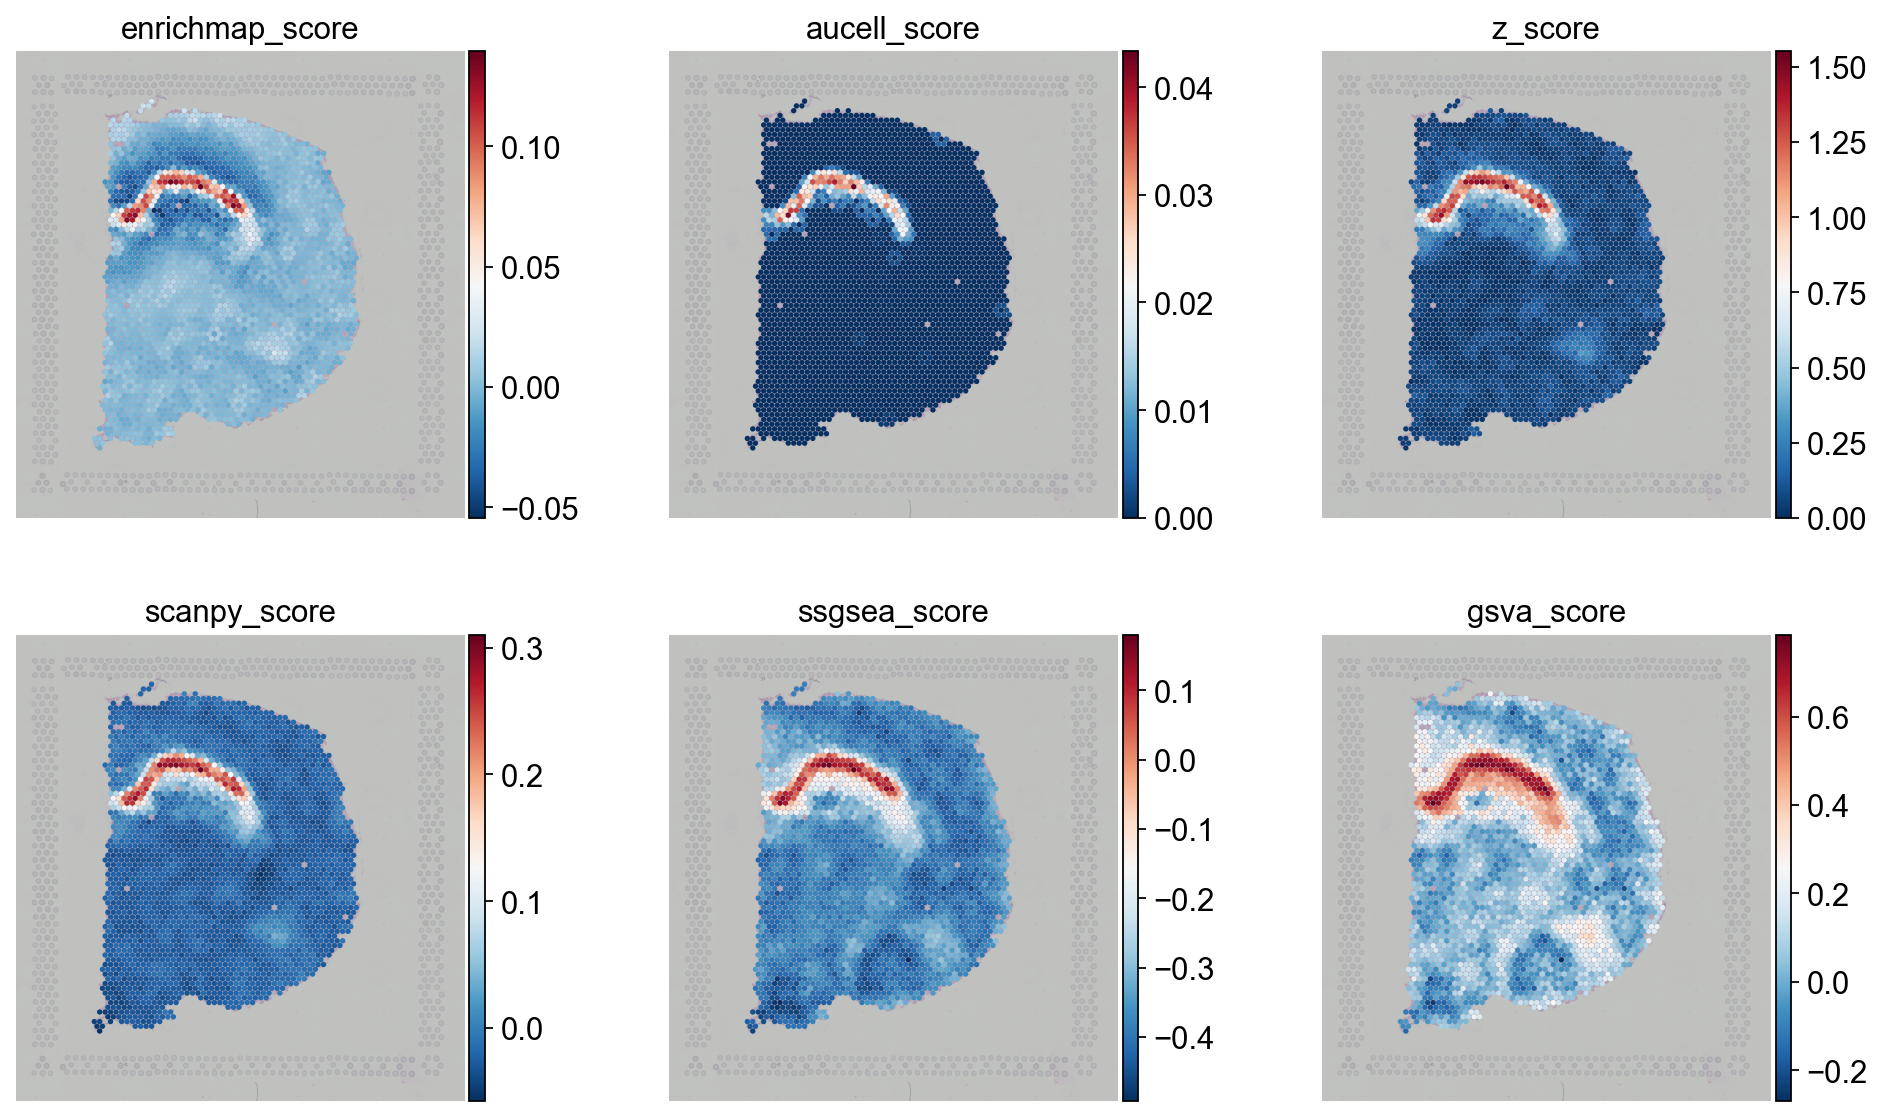

In [29]:
sq.pl.spatial_scatter(
    adata,
    color=methods,
    img_alpha=0.5,
    size=spot_size,
    ncols=3,
    cmap="RdBu_r",
    save="visium_brain_enrichmap_score_all_not_scaled_with_smoothing.pdf",
)

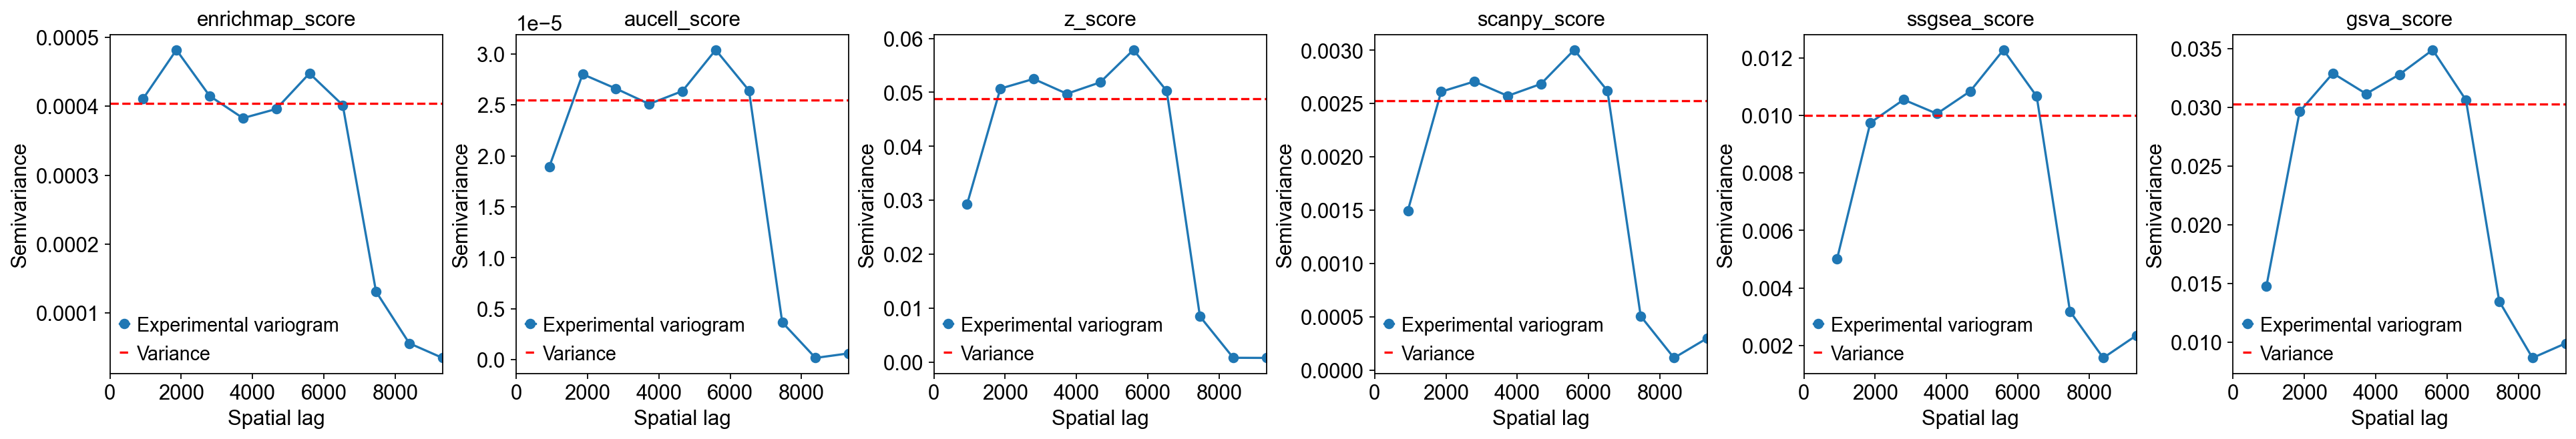

In [30]:
em.pl.variogram(
    adata,
    score_keys=methods,
    save="visium_brain_enrichmap_score_variogram_with_smoothing.pdf",
    lag_percentile=100,
)

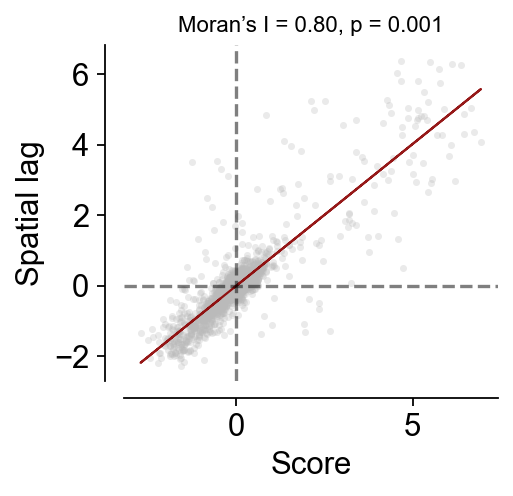

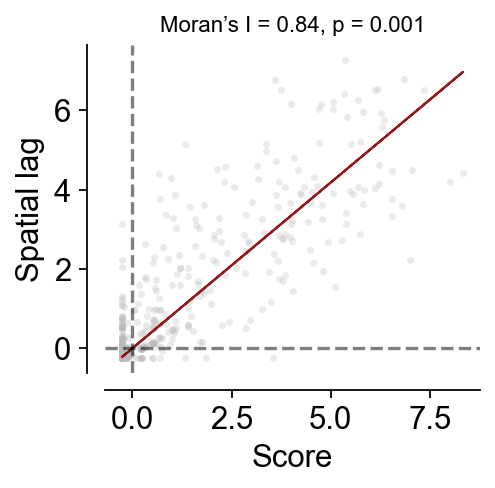

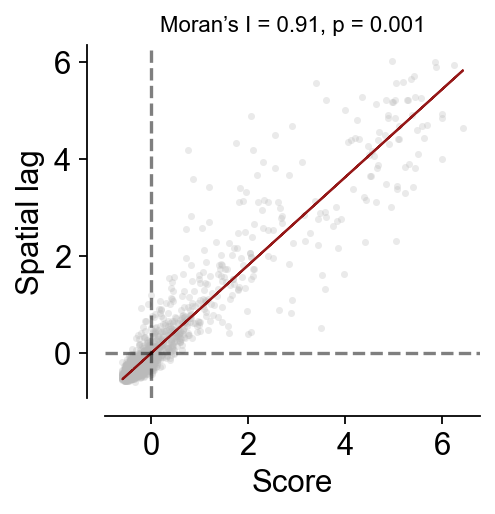

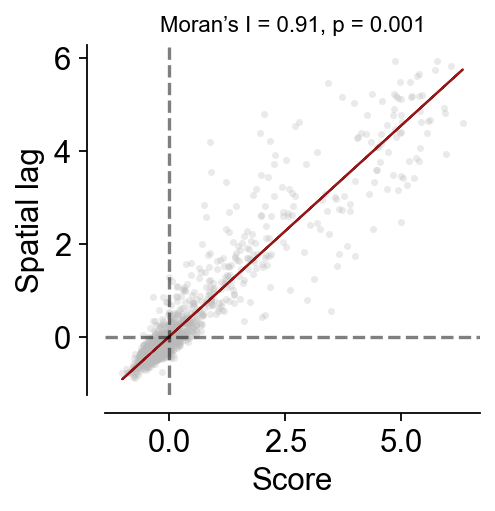

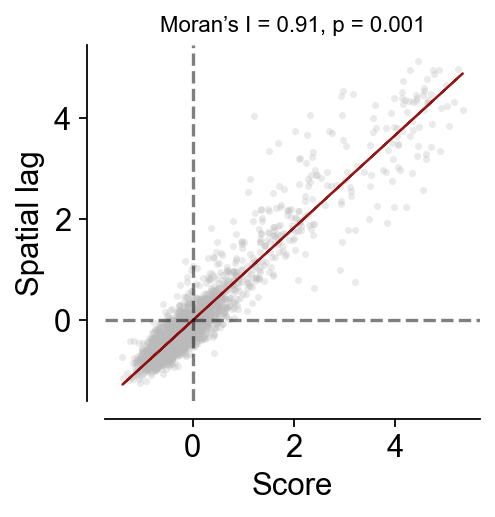

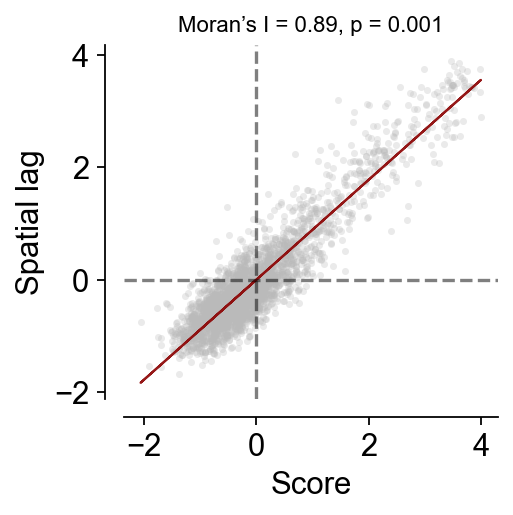

In [31]:
for method in methods:
    em.pl.morans_correlogram(
        adata,
        score_key=method,
        save=f"visium_brain_{method}_morans_correlogram_with_smoothing.pdf",
    )

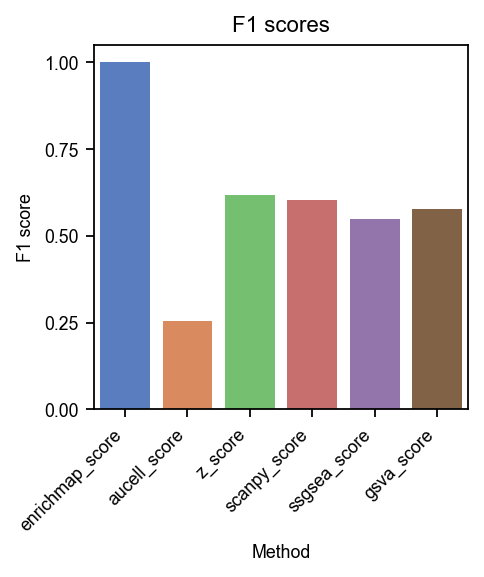

In [32]:
signature_name = "enrichmap"
binary_labels = em.tl.generate_binary_labels(adata, signature_name)
f1_scores = em.tl.compute_f1_scores(adata, methods, binary_labels, save=figure_dir + "visium_brain_enrichmap_score_f1_scores_with_smoothing.pdf")